## Settings

In [99]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [100]:
## libraries
import sys
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators
from src.evaluators.metrics import spec_marginal_delta
from src.evaluators.decomposing import (
    train_decomposed_separation,
    train_decomposed_attribution,
    compile_decomposed_separation,
    compile_decomposed_attribution,
    stat_decomposed_summary,
    stat_decomposed_attribution,
    stat_decomposed_test,
)
from src.visualizers.visualizing import plot_decomposition_evidence

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
)

## Initialization

In [101]:
## reproducibility
N_DECIMALS = 2
RANDOM_STATE = 42
N_REPEATS = 30

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [102]:
## train decomposed separation
cached_decomposed_separation = globals().get("results_dict_decomposed_separation")
if (
    not isinstance(cached_decomposed_separation, dict)
    or cached_decomposed_separation.get("n_repeats") != N_REPEATS
    or cached_decomposed_separation.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_separation = train_decomposed_separation(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

In [103]:
## train decomposed residual attribution
cached_decomposed_attribution = globals().get("results_dict_decomposed_attribution")
if (
    not isinstance(cached_decomposed_attribution, dict)
    or cached_decomposed_attribution.get("n_repeats") != N_REPEATS
    or cached_decomposed_attribution.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_attribution = train_decomposed_attribution(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

## Post-Processing

In [104]:
## compile decomposed separation results
results_decomposed_separation, predictions_decomposed_separation = compile_decomposed_separation(
    results = results_dict_decomposed_separation
)

## compile decomposed residual attribution results
results_decomposed_attribution, predictions_decomposed_attribution = compile_decomposed_attribution(
    results = results_dict_decomposed_attribution
)

## Residual Attribution Test
The residual attribution test probes whether, after estimating the capacity stage $C(X)$, the remaining slack is better predicted from dynamics than from topology. Under the additive decomposition $y^* = C(X) + R(Z)$, the residual slack $s = y^* - \hat{C}(X)$ should be more predictable from $Z$ than from $X$. Each contrast is evaluated with a paired one-sided Wilcoxon signed-rank statistic on domain-level mean absolute error (MAE).

- **$H_0$**: Topology predicts residual slack at least as well as dynamics ($\Delta \mathrm{MAE} \le 0$).
- **$H_1$**: Dynamics predict residual slack better than topology ($\Delta \mathrm{MAE} > 0$).

Rejecting $H_0$ establishes that residual slack is more predictably attributable to dynamics than to unrecovered topological information after conditioning on $C(X)$.

### Decomposition Protocol
Separate learners are fit for $X \to s$ and $Z \to s$ within repeated-seed LOGO-CV (domain) splits. Predictions are averaged across seeds, then aggregated to one MAE value per (model $\times$ domain) for each residual-input source.

### Empirical Test Specification
Paired differences are formed as $\Delta \mathrm{MAE} = \mathrm{MAE}_{X \to s} - \mathrm{MAE}_{Z \to s}$ on matched (model $\times$ domain) units. The table reports the paired median shift, rank-biserial effect size, and Holm-adjusted one-sided p-value summarizing whether the dynamics-based residual model consistently outperforms the topology-based residual model.

In [105]:
## one-sided wilcoxon test for residual attribution
results_attribution = stat_decomposed_attribution(
    predictions = predictions_decomposed_attribution,
    decimals = N_DECIMALS,
)

display(results_attribution)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ MAE ≤ 0
H₁: Δ MAE > 0
Median Δ MAE: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor Z -> slack
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ MAE > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,,Median Δ MAE,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,Diff.
Property,Comparison,,,,,,
Residual Attribution,Topology vs Dynamics,0.65,0.52,0.00,0.00,**,Yes


_Residual slack is predicted more accurately from dynamics than from topology, with a positive median MAE shift and a significant one-sided Wilcoxon result. This means the additive decomposition is not splitting predictors into arbitrary blocks. After the capacity component $C(X)$ is removed, the remaining explainable variation aligns with dynamic information rather than leftover topological signal. The result supports a clear division: topology carries baseline capacity, and dynamics carry the residual structure that remains after capacity is accounted for._

## Non-Inferiority Test
The non-inferiority test probes whether the additive decomposition preserves EI transfer performance relative to richer and reduced alternatives. Each alternative specification is compared against the additive reference with a paired one-sided Wilcoxon signed-rank statistic under an empirically derived EI margin $\delta$.

- **$H_0$**: The alternative specification exceeds additive by at least $\delta$ ($\Delta \mathrm{EI} \ge \delta$).
- **$H_1$**: The alternative specification does not exceed additive by $\delta$ ($\Delta \mathrm{EI} < \delta$).

Rejecting $H_0$ supports that the alternative fails to deliver a practically meaningful EI improvement over the additive decomposition.

### Decomposition Protocol
All specifications are fit under repeated-seed LOGO-CV (domain): additive $C(X) + R(Z)$, interaction-augmented residual, interaction-joint, joint, capacity-only, and dynamics-only. Predictions are averaged across seeds before scoring EI per (model $\times$ domain).

### Reporting Convention
The descriptive summary reports median `[IQR]` EI across matched (model $\times$ domain) units, with `VR`, `MV`, and `MS` included as auxiliary frontier diagnostics. This table provides the empirical scale for the non-inferiority comparisons.

### Empirical Test Specification
The margin $\delta$ is set from the interquartile range of additive EI values, anchoring non-inferiority to natural variability under the reference specification. Paired gaps are formed as $\Delta \mathrm{EI} = \mathrm{EI}_{\text{spec}} - \mathrm{EI}_{\text{additive}}$, and the table reports the median paired gap, rank-biserial effect size, Holm-adjusted one-sided p-value, and non-inferiority decision for each alternative specification.

In [106]:
## empirical delta specification
delta_sufficiency = spec_marginal_delta(
    results = results_decomposed_separation,
    feat_value = ["ei"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,  ## iqr range
    decimals = N_DECIMALS
)

## non-inferiority tests for decomposition sufficiency
results_table_decompose = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_sufficiency,
    decimals = N_DECIMALS,
)

display(results_table_decompose)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.09
H₀: Δ EI ≥ δ
H₁: Δ EI < δ
Median Δ EI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor non-inferiority
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
NI.: Yes if Holm-adj. p < 0.05 and Median Δ EI < δ
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ EI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Interaction,0.00,0.91,0.00,0.00,***,Yes
Interaction Joint,-0.01,0.83,0.00,0.00,***,Yes
Joint,-0.01,0.83,0.00,0.00,***,Yes
Capacity Only,-0.01,0.98,0.00,0.00,***,Yes
Dynamics Only,-0.00,0.81,0.00,0.00,***,Yes


In [107]:
## median decomposition metrics by specification
decomposed_summary = stat_decomposed_summary(
    results = results_decomposed_separation,
    decimals = N_DECIMALS
)

display(decomposed_summary)

,EI [IQR],VR,MV,MS
Specification,,,,
Additive,"0.78 [0.74, 0.82]",0.01,0.01,4.79
Interaction,"0.78 [0.73, 0.83]",0.00,0.00,5.27
Interaction Joint,"0.76 [0.74, 0.83]",0.00,0.00,5.60
Joint,"0.76 [0.74, 0.82]",0.00,0.00,4.86
Capacity Only,"0.76 [0.74, 0.80]",0.00,0.00,5.31
Dynamics Only,"0.77 [0.74, 0.83]",0.00,0.00,4.50


_Across all alternative specifications, paired EI shifts remain small relative to the empirical non-inferiority margin, and the Holm-adjusted signed-rank tests support the additive decomposition as non-inferior. This means adding flexible interaction and joint formulations does not enable meaningful gain frontier performance. The simpler log additive factorization already captures the part of the signal that matters for generalization. Together with the residual-attribution result, this supports $C(X) + R(Z)$ as a parsimonious and interpretable decomposition. Topology carries baseline capacity, dynamics carry the remaining structured variation, and the additive form incurs no practical performance penalty._

## Visualization

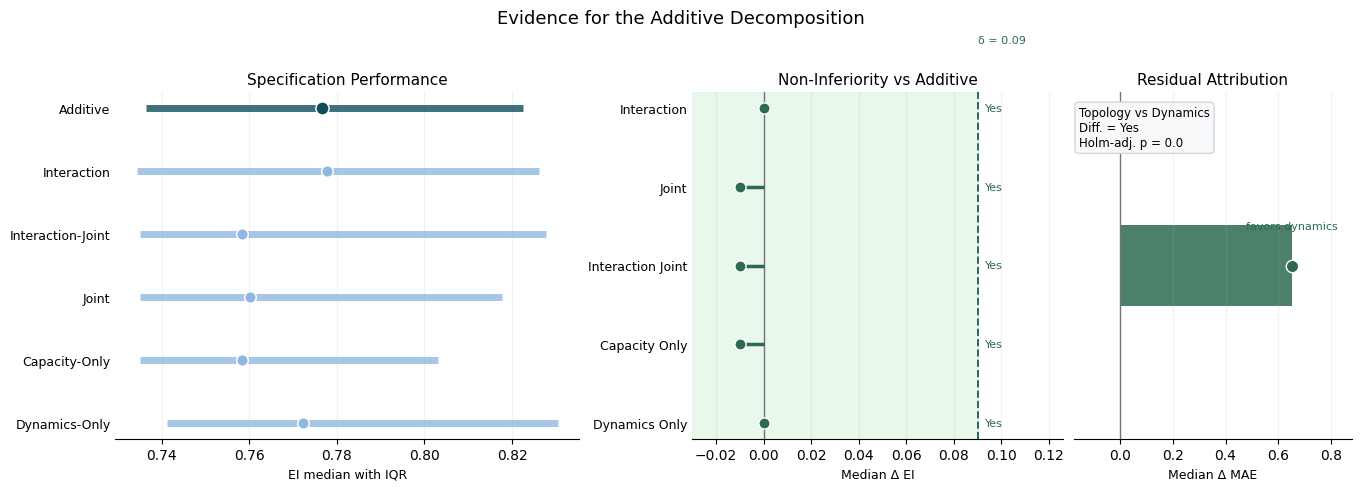

In [108]:
## decomposition evidence figure
fig, axes = plot_decomposition_evidence(
    results = results_decomposed_separation,
    noninferiority = results_table_decompose,
    attribution = results_attribution,
    delta = delta_sufficiency,
    title = "Evidence for the Additive Decomposition",
)